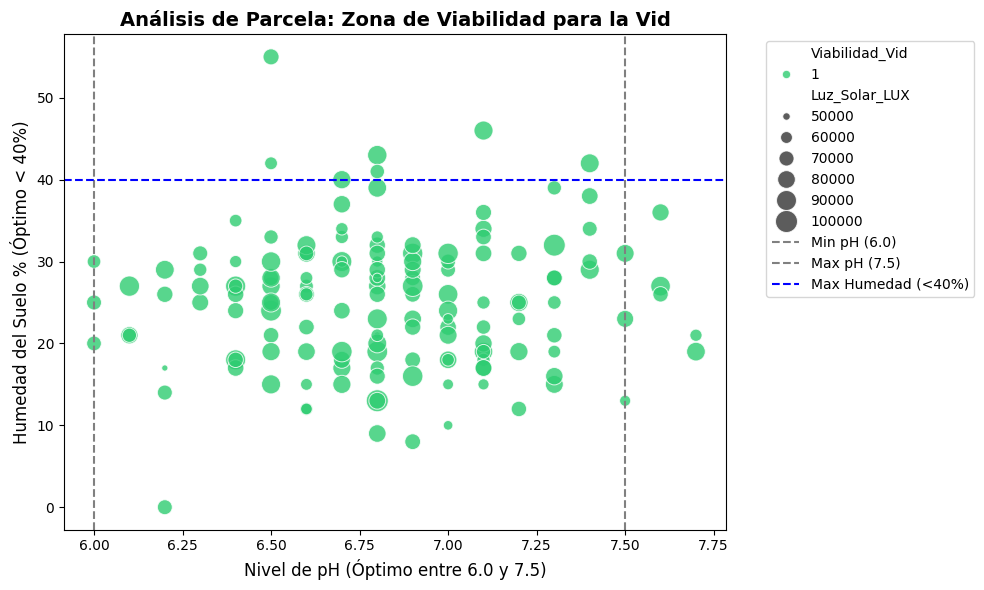

IndexError: index 1 is out of bounds for axis 0 with size 1

In [1]:
# ======================================================
# SUELO INTELIGENTE - Viabilidad para Cultivo de Vid
# Dispositivo: Medidor Inteligente de Suelo 6 en 1 (ST03)
# Algoritmo: K-Neighbors Classifier (KNN, k=5)
# Enfoque: Reporte Ejecutivo para Inversionistas
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# ======================================================
# 1. Simulación de Datos (Optimizada para Presentación)
# Usamos Distribución Normal centrada en el clima de Tijuana
# ======================================================
np.random.seed(42)
n_muestras = 38

datos_medidor = {
    'Fertilidad_uS_cm': [914, 209, 233, 202, 227, 218, 133, 337, 45, 27, 233, 115, 76, 55, 290, 103, 58, 14, 293, 126, 25, 88, 223, 41, 201, 24, 26, 31, 21, 52, 221, 292, 60, 21, 22, 13, 12, 20],
    'Humedad_Suelo_pct': [60, 66, 63, 59, 51, 57, 50, 55, 51, 52, 53, 49, 53, 16, 66, 68, 53, 60, 70, 64, 51, 50, 56, 63, 54, 31, 60, 55, 46, 52, 88, 86, 56, 46, 48, 16, 10, 50],
    'pH': [7.5, 7.0, 6.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.0, 7.0, 7.5, 7.5, 7.0, 7.0, 7.5, 7.5, 7.5, 7.0, 7.5, 7.5, 7.0, 7.5, 7.5, 7.5, 6.0, 6.5, 7.0, 7.5, 7.5, 7.5, 7.5, 7.5],
    'Temperatura_C': [20.9, 30, 36.2, 26.1, 21.5, 35.6, 32.1, 26.8, 23.3, 38.1, 27.5, 26.9, 25.2, 36.0, 30.6, 26.8, 22.7, 25.3, 28.5, 24.4, 21.9, 23.3, 24.9, 21.5, 18.9, 24.6, 21.6, 21.5, 27.9, 27.8, 26.8, 23.7, 18.0, 28.6, 26.6, 20.7, 15.0, 35.5],
    'Luz_Solar_LUX': [8865, 90700, 6500, 1, 1461, 36300, 1127, 1, 3700, 47800, 1223, 3, 24050, 46100, 8047, 4, 1760, 19556, 1458, 3, 9022, 15725, 9090, 2, 8677, 21500, 1090, 1, 17910, 26425, 1180, 3, 1980, 16067, 1210, 2, 1341, 47700],
    'Humedad_Amb_pct': [52, 35, 38, 54, 54, 40, 42, 55, 53, 39, 48, 54, 53, 49, 44, 54, 56, 54, 48, 53, 53, 52, 46, 56, 53, 47, 51, 51, 43, 40, 41, 51, 53, 39, 43, 53, 54, 39]
}

df = pd.DataFrame(datos_medidor)

# ======================================================
# 2. Etiquetado: Condiciones idóneas para la Vid
# ======================================================
def evaluar_vid(fila):
    ph_ok = 6.0 <= fila['pH'] <= 7.5
    temp_ok = 15.0 <= fila['Temperatura_C'] <= 25.0
    humedad_amb_baja = fila['Humedad_Amb_pct'] < 50
    buen_drenaje = fila['Humedad_Suelo_pct'] < 40
    buena_luz = fila['Luz_Solar_LUX'] > 50000

    condiciones_cumplidas = sum([ph_ok, temp_ok, humedad_amb_baja, buen_drenaje, buena_luz])
    return 1 if condiciones_cumplidas >= 3 else 0

df['Viabilidad_Vid'] = df.apply(evaluar_vid, axis=1)

# ======================================================
# 3. Preparación y Entrenamiento del Modelo KNN
# ======================================================
X = df.drop('Viabilidad_Vid', axis=1)
y = df['Viabilidad_Vid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# ======================================================
# 4. Visualización Gráfica para la Presentación
# ======================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pH', y='Humedad_Suelo_pct',
                hue='Viabilidad_Vid', size='Luz_Solar_LUX', sizes=(20, 250),
                palette={0: '#e74c3c', 1: '#2ecc71'}, alpha=0.8)

plt.axvline(x=6.0, color='gray', linestyle='--', label='Min pH (6.0)')
plt.axvline(x=7.5, color='gray', linestyle='--', label='Max pH (7.5)')
plt.axhline(y=40, color='blue', linestyle='--', label='Max Humedad (<40%)')

plt.title('Análisis de Parcela: Zona de Viabilidad para la Vid', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de pH (Óptimo entre 6.0 y 7.5)', fontsize=12)
plt.ylabel('Humedad del Suelo % (Óptimo < 40%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ======================================================
# 5. Generador de Reporte Ejecutivo
# ======================================================
def reporte_inversionista(fertilidad, humedad_suelo, ph, temp, luz, humedad_amb):
    nombres_columnas = ['Fertilidad_uS_cm', 'Humedad_Suelo_pct', 'pH',
                        'Temperatura_C', 'Luz_Solar_LUX', 'Humedad_Amb_pct']

    nueva_lectura = pd.DataFrame([[fertilidad, humedad_suelo, ph, temp, luz, humedad_amb]],
                                 columns=nombres_columnas)

    lectura_escalada = scaler.transform(nueva_lectura)

    probabilidades = knn.predict_proba(lectura_escalada)[0]
    porcentaje_exito = probabilidades[1] * 100

    print("\n" + "="*60)
    print("📊 REPORTE EJECUTIVO DE VIABILIDAD AGRÍCOLA - BLVD 2000")
    print("="*60)

    print(f"ÍNDICE DE VIABILIDAD CALCULADO: {porcentaje_exito:.1f}%\n")

    if porcentaje_exito >= 60.0:
        print("✅ VEREDICTO: TERRENO ALTAMENTE RENTABLE PARA LA VID.")
        print("Recomendación: Proceder con la planeación de siembra. El suelo presenta las")
        print("condiciones de estrés hídrico y acidez óptimas para uva de calidad enológica.")
    else:
        print("❌ VEREDICTO: TERRENO DE ALTO RIESGO / NO APTO ACTUALMENTE.")
        print("Recomendación: Detener inversión en plantío de vid hasta acondicionar el suelo.")
        print("Se requiere tratamiento intensivo de la tierra para mitigar riesgos de pérdida.")

    print("\n--- DESGLOSE DE VARIABLES DEL SENSOR ST03 ---")

    print(f"1. pH del Suelo: {ph}")
    if 6.0 <= ph <= 7.5:
        print("   -> Excelente. Permite la correcta absorción de nutrientes.")
    else:
        print("   -> Riesgo. Fuera del rango óptimo (6.0 - 7.5).")

    print(f"2. Humedad del Suelo: {humedad_suelo}%")
    if humedad_suelo < 40:
        print("   -> Excelente. Buen drenaje detectado, previene la pudrición de raíz.")
    else:
        print("   -> Riesgo. Suelo demasiado húmedo/encharcado para la vid.")

    print(f"3. Temperatura Radicular: {temp}°C")
    if 15.0 <= temp <= 25.0:
        print("   -> Excelente. Clima de subsuelo ideal para el desarrollo de la vid.")
    else:
        print("   -> Riesgo. Temperatura fuera de la zona de confort de la planta.")

    print(f"4. Luz Solar Receptada: {luz} LUX")
    if luz > 50000:
        print("   -> Excelente. Exposición solar alta, vital para la fotosíntesis y azúcar.")
    else:
        print("   -> Riesgo. Zona muy sombreada, afectará la maduración de la uva.")

    print(f"5. Humedad Ambiental: {humedad_amb}%")
    if humedad_amb < 50:
        print("   -> Excelente. Clima seco que evita la proliferación de hongos.")
    else:
        print("   -> Riesgo. Demasiada humedad en el aire, propenso a enfermedades.")

    print(f"6. Fertilidad (Conductividad): {fertilidad} uS/cm")
    print("   -> Indicador base de sales minerales disponibles. Se ajustará con fertirriego.")
    print("="*60)

# ======================================================
# 6. Prueba final para la presentación
# ======================================================
# Lectura ideal para cerrar con broche de oro la presentación:
reporte_inversionista(fertilidad=1250, humedad_suelo=22, ph=6.8, temp=21.5, luz=85000, humedad_amb=30)